In [14405]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn import preprocessing
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import log_loss
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

In [14406]:
data = pd.read_csv('Bank_Personal_Loan_Modelling(1).csv')
data

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1/90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0/40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0/30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0/50,2,0,0,0,0,1,0


In [14407]:
df = pd.DataFrame(data)
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1/90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0/40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0/30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0/50,2,0,0,0,0,1,0


In [14408]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  5000 non-null   int64 
 1   Age                 5000 non-null   int64 
 2   Experience          5000 non-null   int64 
 3   Income              5000 non-null   int64 
 4   ZIP Code            5000 non-null   int64 
 5   Family              5000 non-null   int64 
 6   CCAvg               5000 non-null   object
 7   Education           5000 non-null   int64 
 8   Mortgage            5000 non-null   int64 
 9   Personal Loan       5000 non-null   int64 
 10  Securities Account  5000 non-null   int64 
 11  CD Account          5000 non-null   int64 
 12  Online              5000 non-null   int64 
 13  CreditCard          5000 non-null   int64 
dtypes: int64(13), object(1)
memory usage: 547.0+ KB


In [14409]:
df.isna().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [14410]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [14411]:
for col in df:
    print(f"unique values on column '{col}':")
    print()
    print(df[col].unique())
    print('-' * 100)

unique values on column 'ID':

[   1    2    3 ... 4998 4999 5000]
----------------------------------------------------------------------------------------------------
unique values on column 'Age':

[25 45 39 35 37 53 50 34 65 29 48 59 67 60 38 42 46 55 56 57 44 36 43 40
 30 31 51 32 61 41 28 49 47 62 58 54 33 27 66 24 52 26 64 63 23]
----------------------------------------------------------------------------------------------------
unique values on column 'Experience':

[ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 -1 34  0 38 40 33  4 -2 42 -3 43]
----------------------------------------------------------------------------------------------------
unique values on column 'Income':

[ 49  34  11 100  45  29  72  22  81 180 105 114  40 112 130 193  21  25
  63  62  43 152  83 158  48 119  35  41  18  50 121  71 141  80  84  60
 132 104  52 194   8 131 190  44 139  93 188  39 125  32  20 115  69  85
 135  12 133  19  82 10

In [14412]:
df.duplicated().any()

False

In [14413]:
df['Experience'] = abs(df['Experience'])
print(df['Experience'].unique())

[ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 34  0 38 40 33  4 42 43]


In [14414]:
df['CCAvg'] = df['CCAvg'].str.replace('/', '.').astype(float)

In [14415]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


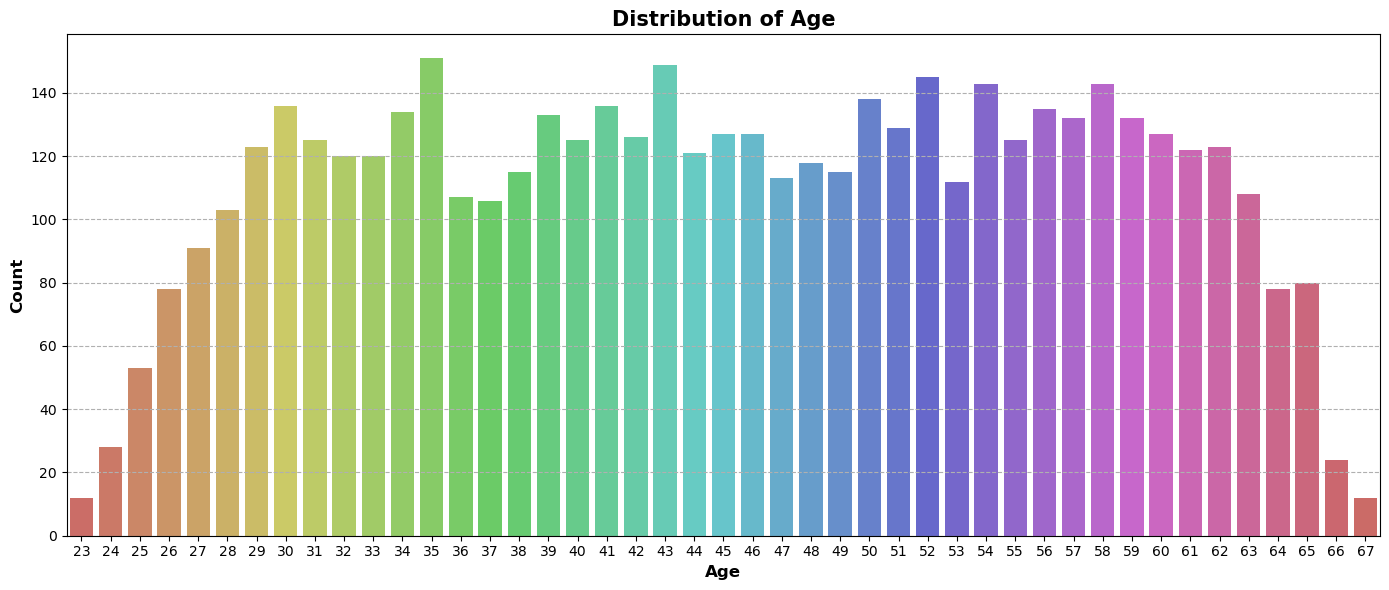

In [14416]:
plt.figure(figsize = (14, 6))
sns.countplot(x = 'Age', data = data, hue = 'Age', legend = False, palette = 'hls')
plt.title('Distribution of Age', fontweight = 'bold', fontsize = 15)
plt.xlabel('Age', fontweight = 'bold', fontsize = 12)
plt.ylabel('Count', fontweight = 'bold', fontsize = 12)
plt.grid(linestyle = '--', axis = 'y')
plt.tight_layout()
plt.show()

People aged 35 have the highest number, followed by those aged 43, 52, 54, and 58, respectively.

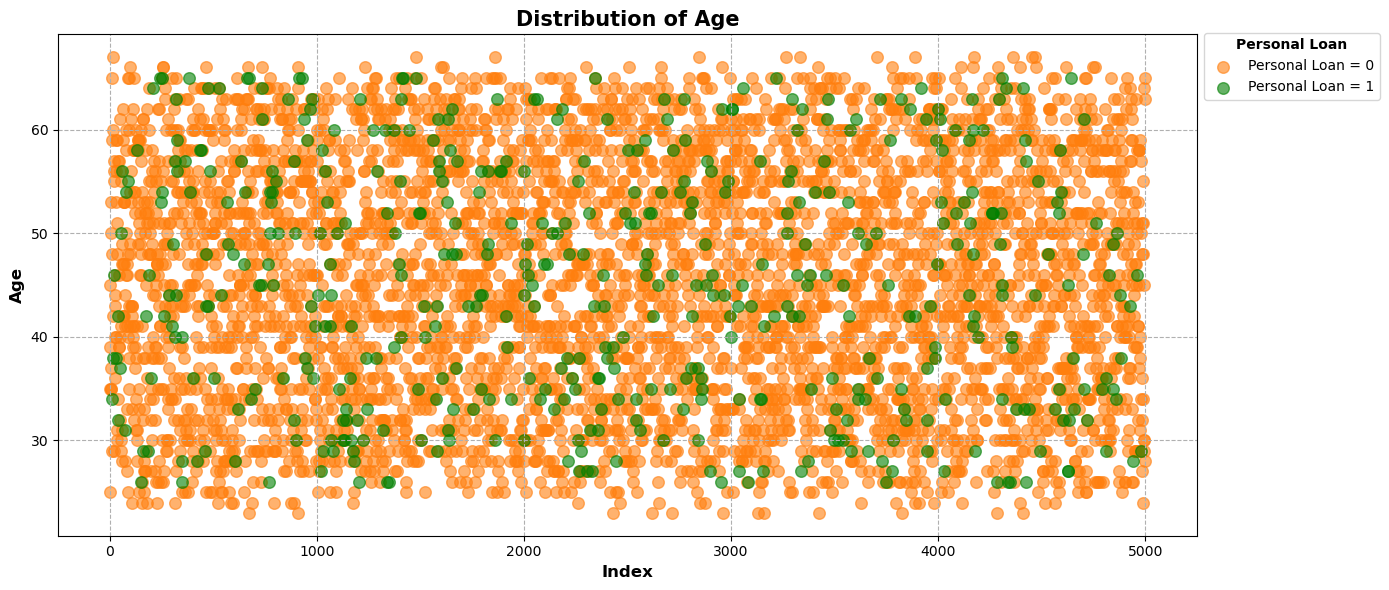

In [14418]:
target_0 = (df['Personal Loan'] == 0)
target_1 = (df['Personal Loan'] == 1)
plt.figure(figsize = (14, 6))
plt.scatter(df.index[target_0], df['Age'][target_0], color = 'tab:orange', alpha = 0.6, s = 70,
           label = 'Personal Loan = 0')
plt.scatter(df.index[target_1], df['Age'][target_1], color = 'green', alpha = 0.6, s = 70,
           label = 'Personal Loan = 1')
plt.title('Distribution of Age', fontweight = 'bold', fontsize = 15)
plt.xlabel('Index', fontweight = 'bold', fontsize = 12)
plt.ylabel('Age', fontweight = 'bold', fontsize = 12)
plt.legend(title = 'Personal Loan', loc = 'upper left', bbox_to_anchor = (1, 1.017),
          title_fontproperties = {'weight':'bold'})
plt.grid(linestyle = '--')
plt.tight_layout()
plt.show()

Based on the chart, no clear correlation can be seen between age and receiving a loan.

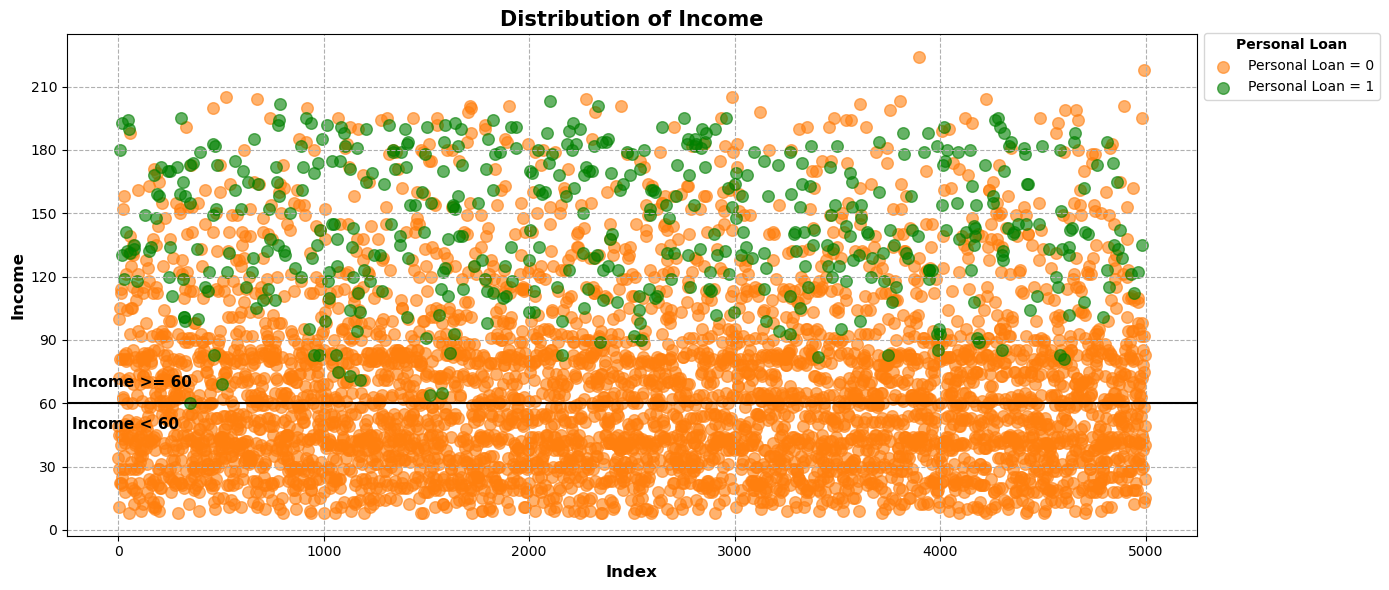

In [14420]:
target_0 = (df['Personal Loan'] == 0)
target_1 = (df['Personal Loan'] == 1)
plt.figure(figsize = (14, 6))
plt.scatter(df.index[target_0], df['Income'][target_0], color = 'tab:orange', alpha = 0.6, s = 70,
           label = 'Personal Loan = 0')
plt.scatter(df.index[target_1], df['Income'][target_1], color = 'green', alpha = 0.6, s = 70,
           label = 'Personal Loan = 1')
plt.title('Distribution of Income', fontweight = 'bold', fontsize = 15)
plt.xlabel('Index', fontweight = 'bold', fontsize = 12)
plt.ylabel('Income', fontweight = 'bold', fontsize = 12)
plt.yticks(range(0, 240, 30))
plt.axhline(60, color = 'black')
plt.text(65, 70, 'Income >= 60', fontsize = 11, fontweight = 'bold',
         ha = 'center', va = 'center', color = 'black')
plt.text(35, 50, 'Income < 60', fontsize = 11, fontweight = 'bold',
        ha = 'center', va = 'center', color = 'black')
plt.legend(title = 'Personal Loan', loc = 'upper left', bbox_to_anchor = (1, 1.017),
          title_fontproperties = {'weight':'bold'})
plt.grid(linestyle = '--')
plt.tight_layout()
plt.show()


According to the chart, only individuals with an income of 60 or higher have received a personal loan, while those with an income below 60 have not.

In [14422]:
zip_code_data = pd.read_csv('zip_code_database (1).csv')
zip_code_df = pd.DataFrame(zip_code_data)
zip_code_df

,zip,type,decommissioned,primary_city,acceptable_cities,unacceptable_cities,state,county,timezone,area_codes,world_region,country,latitude,longitude,irs_estimated_population
0,501,UNIQUE,0,Holtsville,NaN,Internal Revenue Service,NY,Suffolk County,America/New_York,631,NaN,US,40.81,-73.04,562
1,544,UNIQUE,0,Holtsville,NaN,Internal Revenue Service,NY,Suffolk County,America/New_York,631,NaN,US,40.81,-73.04,0
2,601,STANDARD,0,Adjuntas,NaN,"Colinas Del Gigante, Jard De Adjuntas, Urb San...",PR,Adjuntas Municipio,America/Puerto_Rico,"787, 939",NaN,US,18.16,-66.72,0
3,602,STANDARD,0,Aguada,NaN,"Alts De Aguada, Bo Guaniquilla, Comunidad Las ...",PR,Aguada Municipio,America/Puerto_Rico,"787, 939",NaN,US,18.38,-67.18,0
4,603,STANDARD,0,Aguadilla,Ramey,"Bda Caban, Bda Esteves, Bo Borinquen, Bo Ceiba...",PR,Aguadilla Municipio,America/Puerto_Rico,"787, 939",NaN,US,18.43,-67.15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42730,99926,PO BOX,0,Metlakatla,NaN,NaN,AK,Prince of Wales-Hyder Census Area,America/Metlakatla,907,NaN,US,55.14,-131.49,1140
42731,99927,PO BOX,0,Point Baker,NaN,NaN,AK,Prince of Wales-Hyder Census Area,America/Sitka,907,NaN,US,56.33,-133.61,48
42732,99928,PO BOX,0,Ward Cove,NaN,NaN,AK,Ketchikan Gateway Borough,America/Sitka,907,NaN,US,55.45,-131.79,1530
42733,99929,PO BOX,0,Wrangell,NaN,NaN,AK,Wrangell City and Borough,America/Sitka,"236, 250, 672, 778, 907",NaN,US,56.41,-131.61,2145


In [14423]:
zip_code_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42735 entries, 0 to 42734
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   zip                       42735 non-null  int64  
 1   type                      42735 non-null  object 
 2   decommissioned            42735 non-null  int64  
 3   primary_city              42735 non-null  object 
 4   acceptable_cities         9302 non-null   object 
 5   unacceptable_cities       11673 non-null  object 
 6   state                     42735 non-null  object 
 7   county                    41806 non-null  object 
 8   timezone                  41944 non-null  object 
 9   area_codes                41919 non-null  object 
 10  world_region              333 non-null    object 
 11  country                   42657 non-null  object 
 12  latitude                  42735 non-null  float64
 13  longitude                 42735 non-null  float64
 14  irs_es

In [14424]:

zip_code_df = zip_code_df.drop(['type', 'decommissioned', 'acceptable_cities', 'unacceptable_cities',
                                'world_region', 'irs_estimated_population', 'state', 'county',
                                'country', 'area_codes', 'timezone'], axis = 1)
zip_code_df

,zip,primary_city,latitude,longitude
0,501,Holtsville,40.81,-73.04
1,544,Holtsville,40.81,-73.04
2,601,Adjuntas,18.16,-66.72
3,602,Aguada,18.38,-67.18
4,603,Aguadilla,18.43,-67.15
...,...,...,...,...
42730,99926,Metlakatla,55.14,-131.49
42731,99927,Point Baker,56.33,-133.61
42732,99928,Ward Cove,55.45,-131.79
42733,99929,Wrangell,56.41,-131.61


In [14425]:
zip_code_df = zip_code_df.rename(columns = {'zip': 'ZIP Code'})

In [14426]:
df = pd.merge(df, zip_code_df, on = 'ZIP Code', how = 'left')
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,primary_city,latitude,longitude
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,Pasadena,34.16,-118.08
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,Los Angeles,34.02,-118.29
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,Berkeley,37.87,-122.25
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,San Francisco,37.72,-122.44
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,Northridge,34.24,-118.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0,Irvine,33.65,-117.85
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0,La Jolla,32.86,-117.24
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0,Ojai,34.51,-119.29
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0,Los Angeles,34.03,-118.40


In [14427]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
 14  primary_city        4967 non-null   object 
 15  latitude            4967 non-null   float64
 16  longit

In [14428]:
df.isna().sum()

ID                     0
Age                    0
Experience             0
Income                 0
ZIP Code               0
Family                 0
CCAvg                  0
Education              0
Mortgage               0
Personal Loan          0
Securities Account     0
CD Account             0
Online                 0
CreditCard             0
primary_city          33
latitude              33
longitude             33
dtype: int64

In [14429]:
df.dropna(inplace = True)
df.isna().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
primary_city          0
latitude              0
longitude             0
dtype: int64

In [14430]:
fig = px.scatter_mapbox(df,
                       lat = df['latitude'],
                       lon = df['longitude'],
                       hover_name = df['primary_city'],
                       zoom = 5,
                       color = df['Personal Loan'],
                       color_continuous_scale = "Viridis",
                       width = 1100,
                       height = 600,
                       title = '<b>Distribution of Cities</b>')
fig.update_layout(mapbox_style = 'open-street-map')
fig.update_layout(margin = {'r': 0, 't': 50, 'l': 0, 'b': 10},
                     title={'x':0.5, 'xanchor':'center', 'yanchor':'top'})
fig.show()

Most of the people whose information has been recorded are located in the Los Angeles and San Francisco areas.

The highest number of loan recipients are also from the Los Angeles area.

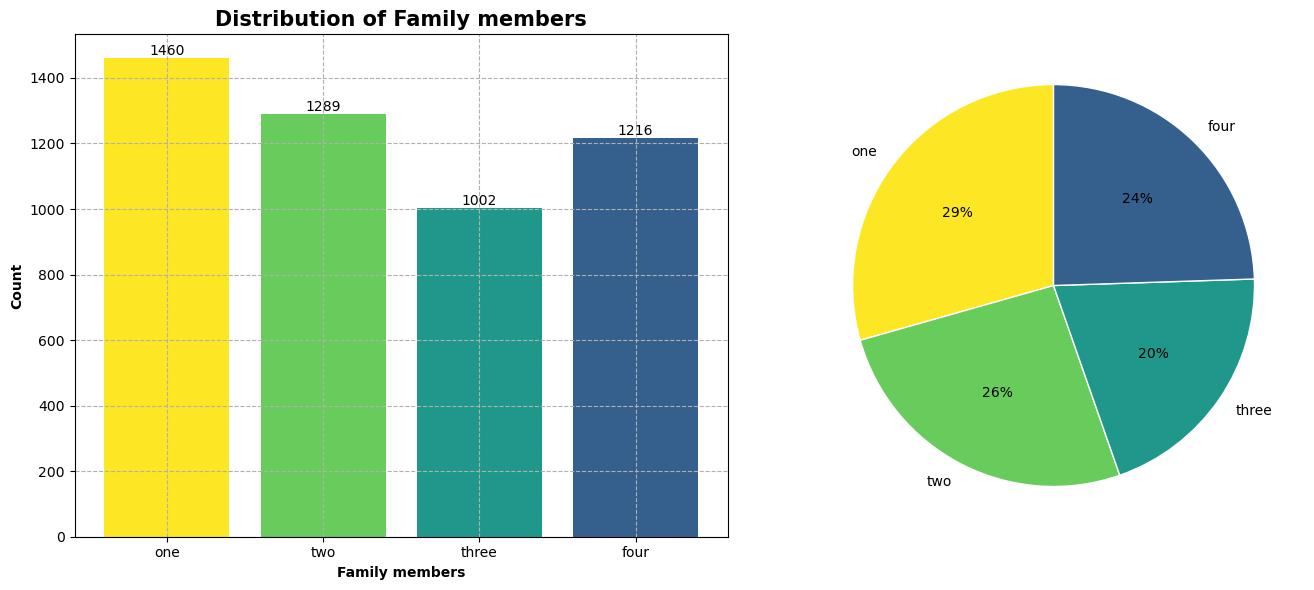

In [14432]:
one_member = 0
two_members = 0
three_members = 0
four_members = 0

for item in df['Family']:
    if item == 1:
        one_member += 1
    if item == 2:
        two_members += 1
    if item == 3:
        three_members += 1
    if item == 4:
        four_members += 1

family_members = ['one', 'two', 'three', 'four']
family_members_values = [one_member, two_members, three_members, four_members]

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(1, 0.3, len(family_members)))

fig, ax = plt.subplots(1, 2, figsize = (14, 6))
bar_container = ax[0].bar(family_members, family_members_values, color = colors)
ax[0].bar_label(bar_container)
ax[0].set_title('Distribution of Family members', fontweight = 'bold', fontsize = 15)
ax[0].set_xlabel('Family members', fontweight = 'bold')
ax[0].set_ylabel('Count', fontweight = 'bold')
ax[0].grid(linestyle = '--')

ax[1].pie(family_members_values, labels = family_members , autopct = '%1.0f%%',
          startangle = 90, colors = colors, wedgeprops = {'edgecolor': 'white'})

plt.tight_layout()
plt.show()

Most people (29%) are single, meaning they have a one-person household.

26% of people have a two-person household.

24% have a four-person household.

20% have a three-person household.

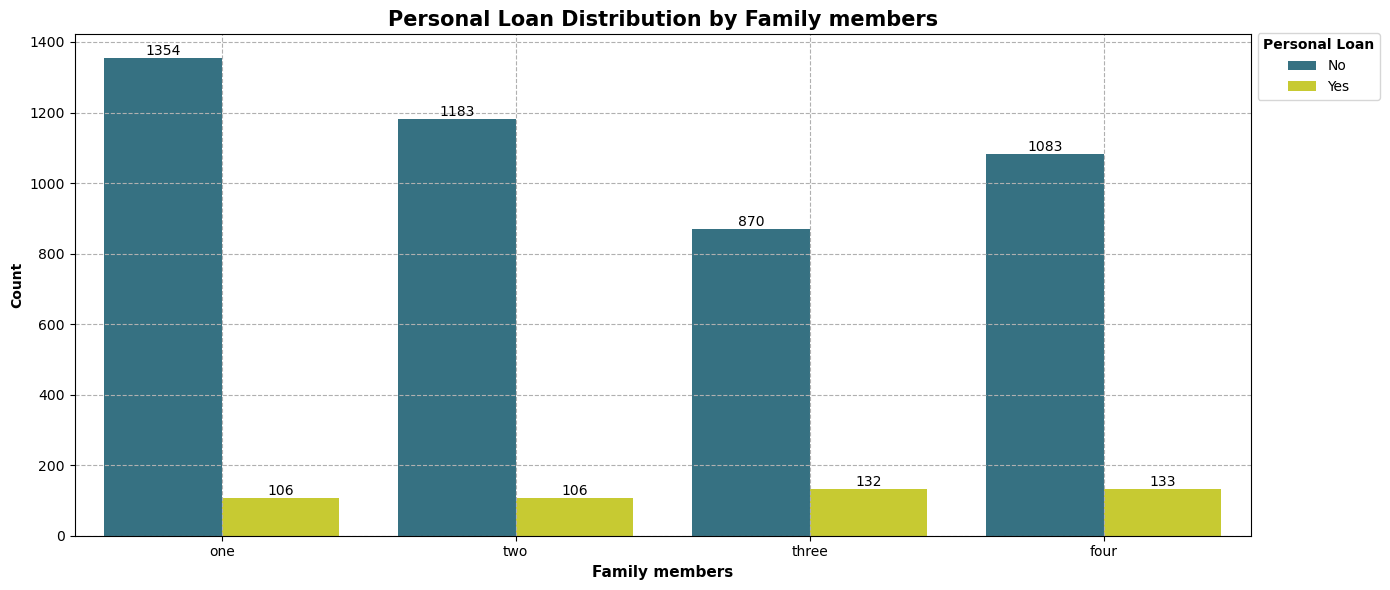

In [14434]:
target_vs_family = df.groupby(['Personal Loan', 'Family']).size().reset_index(name = 'target_count')
target_vs_family['target_label'] = target_vs_family['Personal Loan'].map({0:'No', 1:'Yes'})
target_vs_family['family_label'] = target_vs_family['Family'].map({
    1:'one', 2:'two', 3:'three', 4:'four'})

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.4, 0.95, target_vs_family['target_label'].nunique())).tolist()

plt.figure(figsize = (14, 6))
ax = sns.barplot(data = target_vs_family, x = 'family_label', y = 'target_count',
                 hue = 'target_label', palette = colors)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Personal Loan Distribution by Family members', fontweight = 'bold', fontsize = 15)
plt.xlabel('Family members', fontweight = 'bold', fontsize = 11)
plt.ylabel('Count', fontweight = 'bold')
plt.grid(linestyle = '--')
plt.legend(title = 'Personal Loan', loc = 'upper left', bbox_to_anchor = (1, 1.017),
           title_fontproperties = {'weight':'bold'})

plt.tight_layout()
plt.show()

Most of the people who have taken out loans have three- or four-person households.

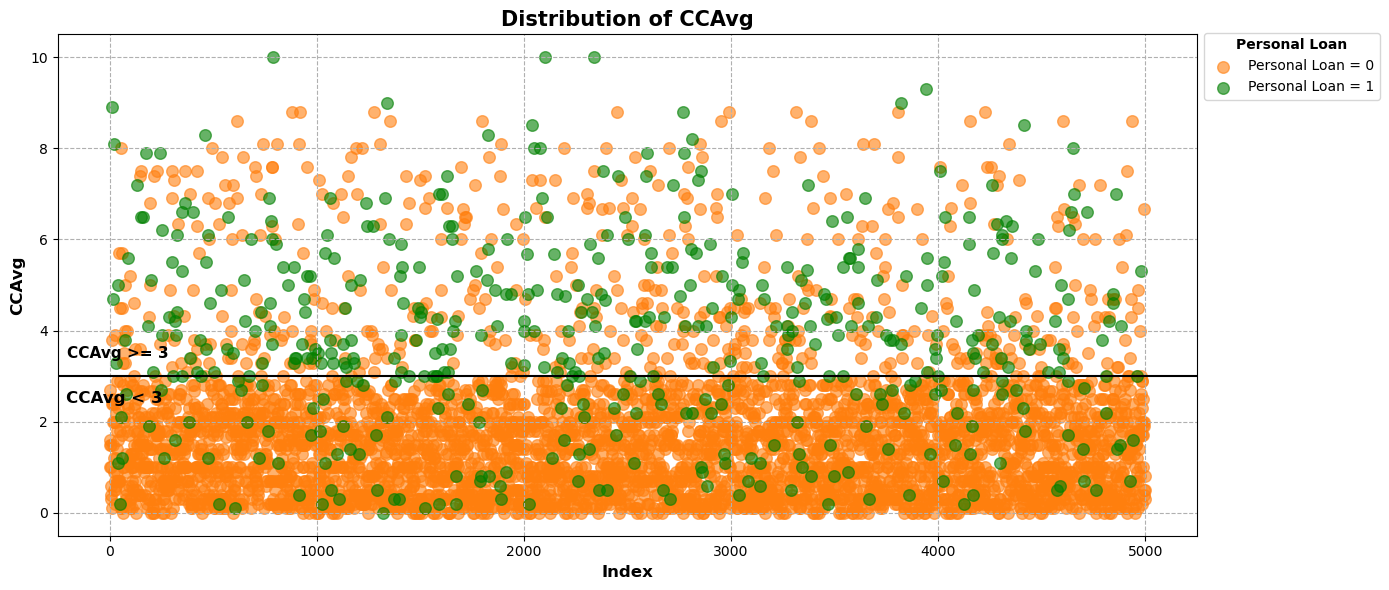

In [14436]:
target_0 = (df['Personal Loan'] == 0)
target_1 = (df['Personal Loan'] == 1)
plt.figure(figsize = (14, 6))
plt.scatter(df.index[target_0], df['CCAvg'][target_0], color = 'tab:orange', alpha = 0.6, s = 70,
           label = 'Personal Loan = 0')
plt.scatter(df.index[target_1], df['CCAvg'][target_1], color = 'green', alpha = 0.6, s = 70,
           label = 'Personal Loan = 1')
plt.title('Distribution of CCAvg', fontweight = 'bold', fontsize = 15)
plt.xlabel('Index', fontweight = 'bold', fontsize = 12)
plt.ylabel('CCAvg', fontweight = 'bold', fontsize = 12)
plt.axhline(3, color = 'black')
plt.text(40, 3.5, 'CCAvg >= 3', fontsize = 11, fontweight = 'bold',
         ha = 'center', va = 'center', color = 'black')
plt.text(20, 2.5, 'CCAvg < 3', fontsize = 12, fontweight = 'bold',
        ha = 'center', va = 'center', color = 'black')
plt.legend(title = 'Personal Loan', loc = 'upper left', bbox_to_anchor = (1, 1.017),
          title_fontproperties = {'weight':'bold'})
plt.grid(linestyle = '--')
plt.tight_layout()
plt.show()

Most people have a CCAvg of less than 3.

Those who have taken out loans mostly have a CCAvg greater than 3.

It can be said that having a CCAvg of 3 or higher increases the likelihood of receiving a loan.

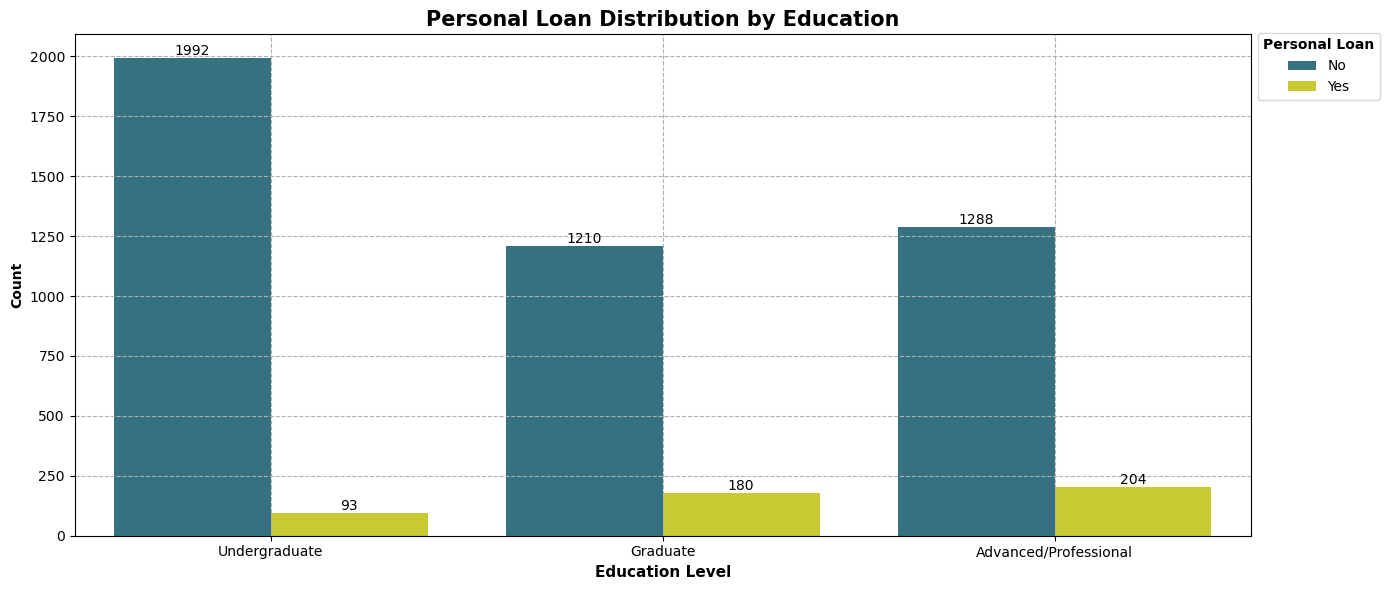

In [14438]:

target_vs_education = df.groupby(['Personal Loan', 'Education']).size().reset_index(name = 'target_count')
target_vs_education['target_label'] = target_vs_education['Personal Loan'].map({0:'No', 1:'Yes'})
target_vs_education['education_label'] = target_vs_education['Education'].map({
    1:'Undergraduate', 2:'Graduate', 3:'Advanced/Professional'})

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.4, 0.95, target_vs_education['target_label'].nunique())).tolist()

plt.figure(figsize = (14, 6))
ax = sns.barplot(data = target_vs_education, x = 'education_label', y = 'target_count',
                 hue = 'target_label', palette = colors)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Personal Loan Distribution by Education', fontweight = 'bold', fontsize = 15)
plt.xlabel('Education Level', fontweight = 'bold', fontsize = 11)
plt.ylabel('Count', fontweight = 'bold')
plt.grid(linestyle = '--')
plt.legend(title = 'Personal Loan', loc = 'upper left', bbox_to_anchor = (1, 1.017),
           title_fontproperties = {'weight':'bold'})

plt.tight_layout()
plt.show()

The number of people at different education levels is as follows:

Undergraduate > Advanced/Professional > Graduate

The number of people who have successfully received a loan at different education levels is as follows:

Advanced/Professional > Graduate > Undergraduate

It can be said that the higher the education level, the greater the chance of receiving a loan.

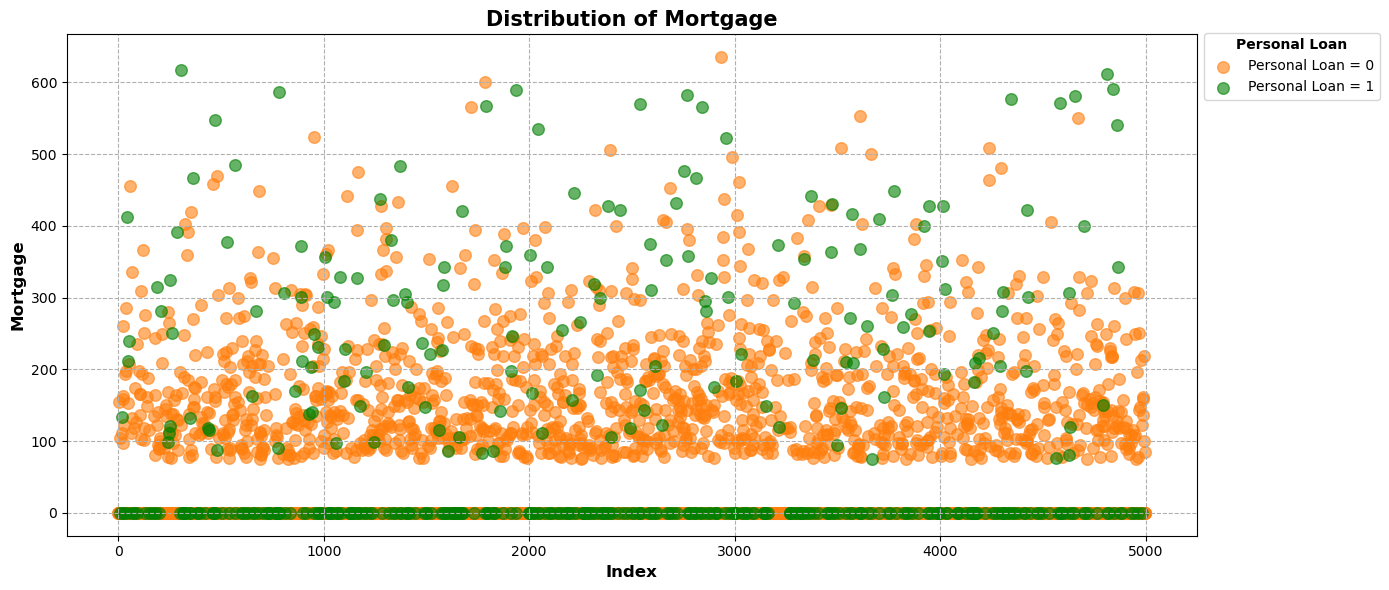

In [14440]:
target_0 = (df['Personal Loan'] == 0)
target_1 = (df['Personal Loan'] == 1)
plt.figure(figsize = (14, 6))
plt.scatter(df.index[target_0], df['Mortgage'][target_0], color = 'tab:orange', alpha = 0.6, s = 70,
           label = 'Personal Loan = 0')
plt.scatter(df.index[target_1], df['Mortgage'][target_1], color = 'green', alpha = 0.6, s = 70,
           label = 'Personal Loan = 1')
plt.title('Distribution of Mortgage', fontweight = 'bold', fontsize = 15)
plt.xlabel('Index', fontweight = 'bold', fontsize = 12)
plt.ylabel('Mortgage', fontweight = 'bold', fontsize = 12)
plt.legend(title = 'Personal Loan', loc = 'upper left', bbox_to_anchor = (1, 1.017),
          title_fontproperties = {'weight':'bold'})
plt.grid(linestyle = '--')
plt.tight_layout()
plt.show()

People who do not own a house or whose house has very low value (Mortgage = 0) have a higher chance of receiving a loan.

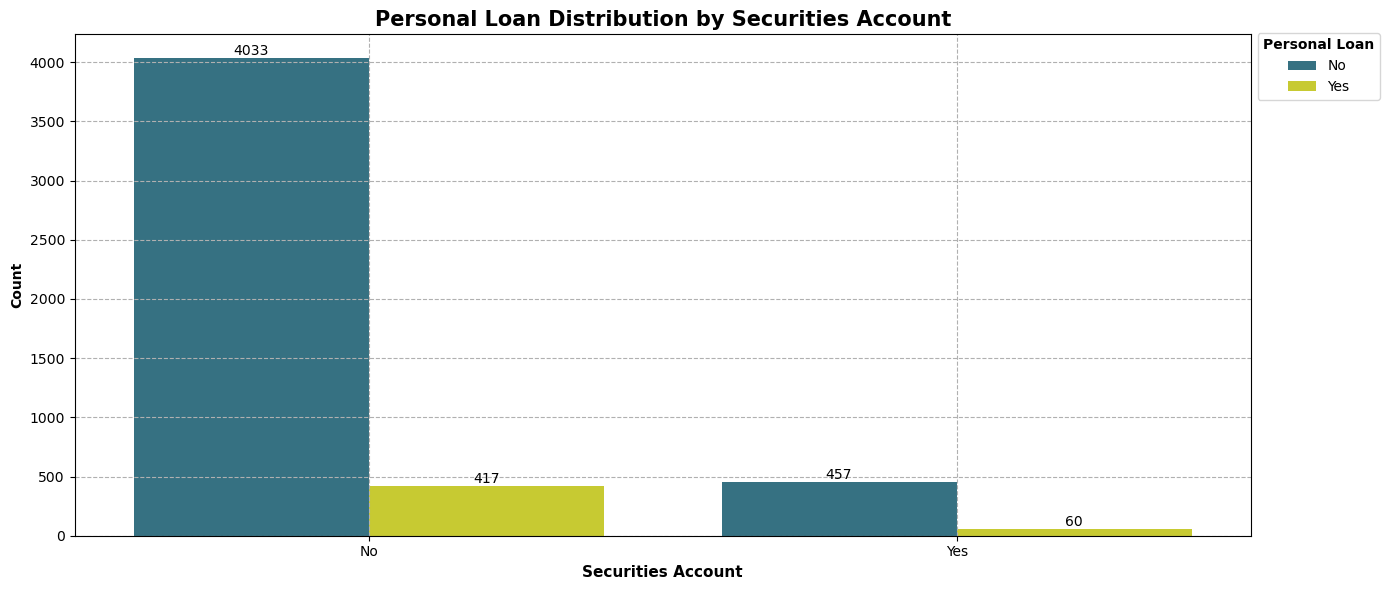

In [14442]:

target_vs_SecuritiesAccount = df.groupby(['Personal Loan',
                                  'Securities Account']).size().reset_index(name = 'target_count')
target_vs_SecuritiesAccount['target_label'] = target_vs_SecuritiesAccount['Personal Loan'].map({
    0:'No', 1:'Yes'})
target_vs_SecuritiesAccount['SecuritiesAccount_label'] = target_vs_SecuritiesAccount['Securities Account'].map({
    0:'No', 1:'Yes'})

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.4, 0.95, target_vs_SecuritiesAccount['target_label'].nunique())).tolist()

plt.figure(figsize = (14, 6))
ax = sns.barplot(data = target_vs_SecuritiesAccount, x = 'SecuritiesAccount_label', y = 'target_count',
                 hue = 'target_label', palette = colors)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Personal Loan Distribution by Securities Account', fontweight = 'bold', fontsize = 15)
plt.xlabel('Securities Account', fontweight = 'bold', fontsize = 11)
plt.ylabel('Count', fontweight = 'bold')
plt.grid(linestyle = '--')
plt.legend(title = 'Personal Loan', loc = 'upper left', bbox_to_anchor = (1, 1.017),
           title_fontproperties = {'weight':'bold'})

plt.tight_layout()
plt.show()

Most people do not have a Securities Account.

The majority of those who have received loans also do not have a Securities Account.

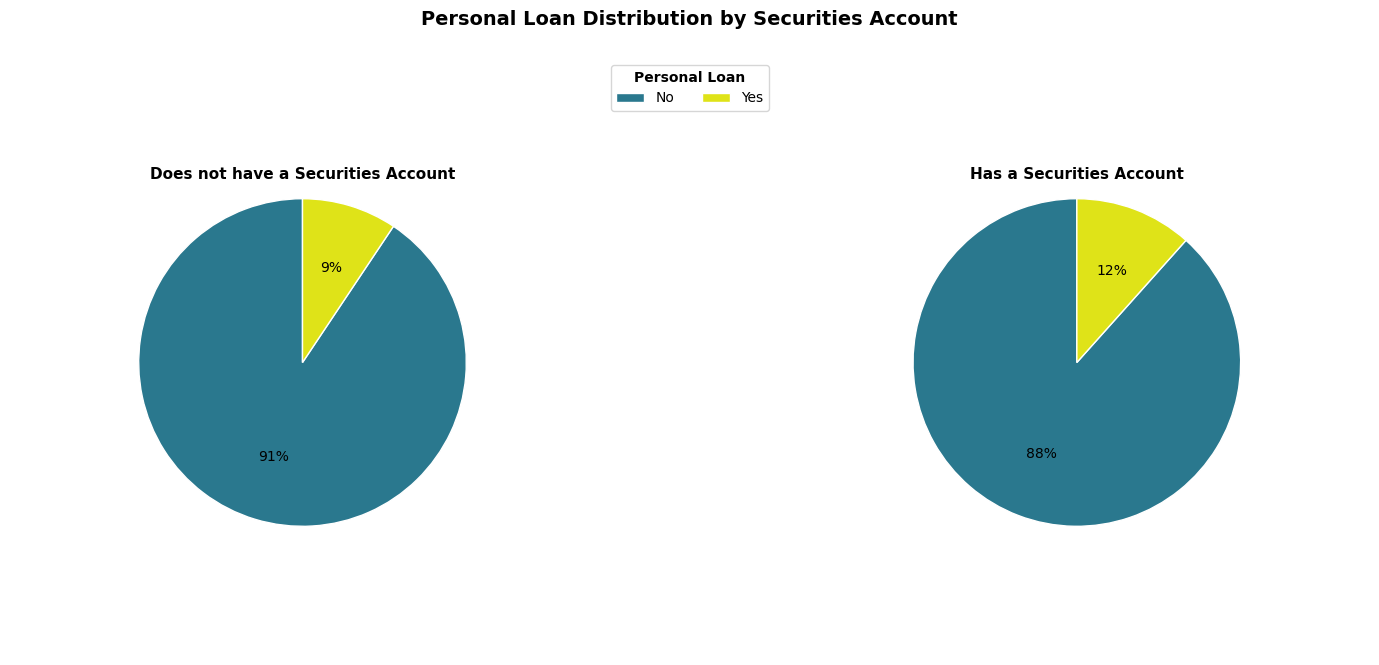

In [14444]:

SecuritiesAccount_labels = {
    0: 'Does not have a Securities Account',
    1: 'Has a Securities Account'
}
target_labels = {0: 'No', 1: 'Yes'}

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.4, 0.95, len(target_labels)))

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

legend_handles = None

for i, SecuritiesAccount_value in enumerate(sorted(df['Securities Account'].unique())):
    ax = axes[i]
    subset = df[df['Securities Account'] == SecuritiesAccount_value]
    
    counts = subset['Personal Loan'].value_counts().reindex([0, 1], fill_value = 0)
    
    wedges, _, autotexts = ax.pie(counts, labels = None, autopct = '%1.0f%%', startangle = 90,
                                  colors = colors, wedgeprops = {'edgecolor': 'white'}, radius = 0.7)
    
    ax.set_title(f"{SecuritiesAccount_labels[SecuritiesAccount_value]}", fontsize = 11,
                 fontweight = 'bold', y = 0.8)
    
    if i == 0:
        legend_handles = wedges

plt.suptitle('Personal Loan Distribution by Securities Account',
             fontsize = 14, fontweight = 'bold', y = 1.10)

fig.legend(legend_handles, ['No', 'Yes'],
           title = 'Personal Loan', loc = 'upper center', bbox_to_anchor = (0.5, 1.02),
           ncol = 2, title_fontproperties = {'weight': 'bold'})

plt.tight_layout()
plt.subplots_adjust(wspace = 0.3, top = 1)
plt.show()

A higher percentage of those who had a Securities Account succeeded in obtaining a loan. However, the difference is not large, so it cannot be stated with certainty that having a Securities Account increases the chances of receiving a loan.

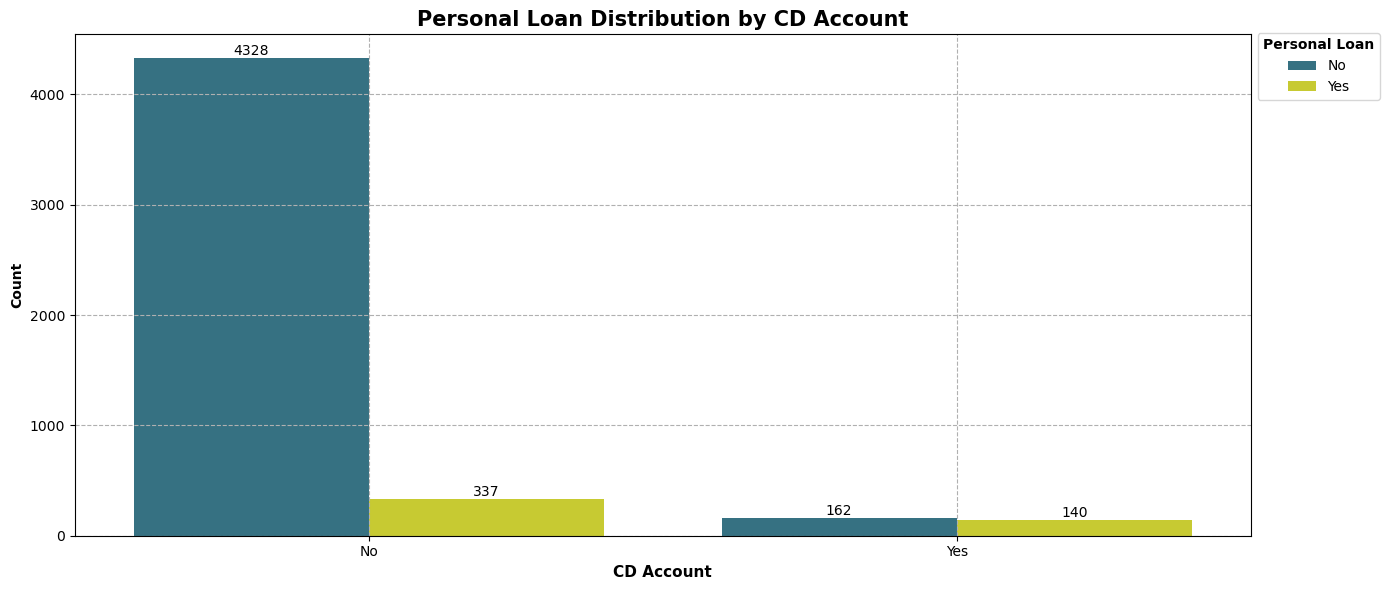

In [14446]:

target_vs_CDAccount = df.groupby(['Personal Loan',
                                  'CD Account']).size().reset_index(name = 'target_count')
target_vs_CDAccount['target_label'] = target_vs_CDAccount['Personal Loan'].map({
    0:'No', 1:'Yes'})
target_vs_CDAccount['CDAccount_label'] = target_vs_CDAccount['CD Account'].map({
    0:'No', 1:'Yes'})

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.4, 0.95, target_vs_CDAccount['target_label'].nunique())).tolist()

plt.figure(figsize = (14, 6))
ax = sns.barplot(data = target_vs_CDAccount, x = 'CDAccount_label', y = 'target_count',
                 hue = 'target_label', palette = colors)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Personal Loan Distribution by CD Account', fontweight = 'bold', fontsize = 15)
plt.xlabel('CD Account', fontweight = 'bold', fontsize = 11)
plt.ylabel('Count', fontweight = 'bold')
plt.grid(linestyle = '--')
plt.legend(title = 'Personal Loan', loc = 'upper left', bbox_to_anchor = (1, 1.017),
           title_fontproperties = {'weight':'bold'})

plt.tight_layout()
plt.show()

Most people do not have a CD Account.

The majority of those who have received loans also do not have a CD Account.

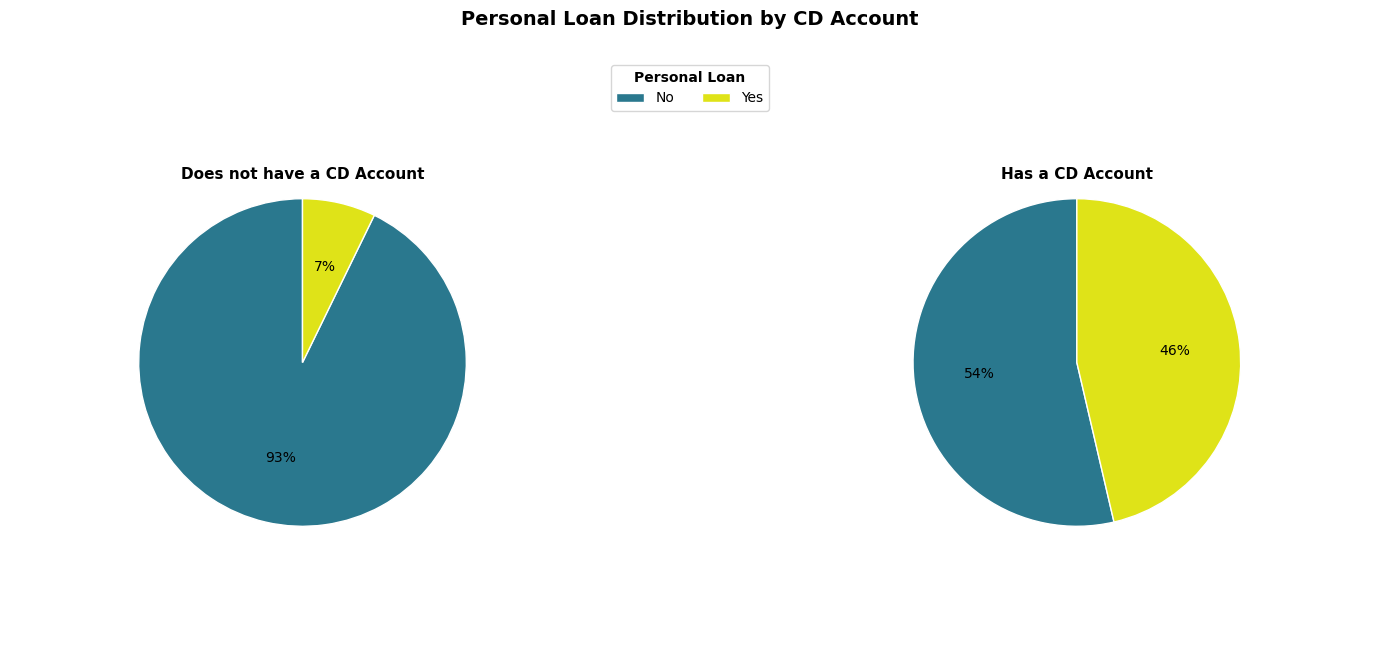

In [14448]:

CDAccount_labels = {
    0: 'Does not have a CD Account',
    1: 'Has a CD Account'
}
target_labels = {0: 'No', 1: 'Yes'}

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.4, 0.95, len(target_labels)))

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

legend_handles = None

for i, CDAccount_value in enumerate(sorted(df['CD Account'].unique())):
    ax = axes[i]
    subset = df[df['CD Account'] == CDAccount_value]
    
    counts = subset['Personal Loan'].value_counts().reindex([0, 1], fill_value = 0)
    
    wedges, _, autotexts = ax.pie(counts, labels = None, autopct = '%1.0f%%', startangle = 90,
                                  colors = colors, wedgeprops = {'edgecolor': 'white'}, radius = 0.7)
    
    ax.set_title(f"{CDAccount_labels[CDAccount_value]}", fontsize = 11, fontweight = 'bold', y = 0.8)
    
    if i == 0:
        legend_handles = wedges

plt.suptitle('Personal Loan Distribution by CD Account',
             fontsize = 14, fontweight = 'bold', y = 1.10)

fig.legend(legend_handles, ['No', 'Yes'],
           title = 'Personal Loan', loc = 'upper center', bbox_to_anchor = (0.5, 1.02),
           ncol = 2, title_fontproperties = {'weight': 'bold'})

plt.tight_layout()
plt.subplots_adjust(wspace = 0.3, top = 1)
plt.show()

Although the number of individuals with a CD Account who have also taken a Personal Loan is much smaller compared to the other group, the above chart clearly shows that having a CD Account increases the likelihood of obtaining a Personal Loan.

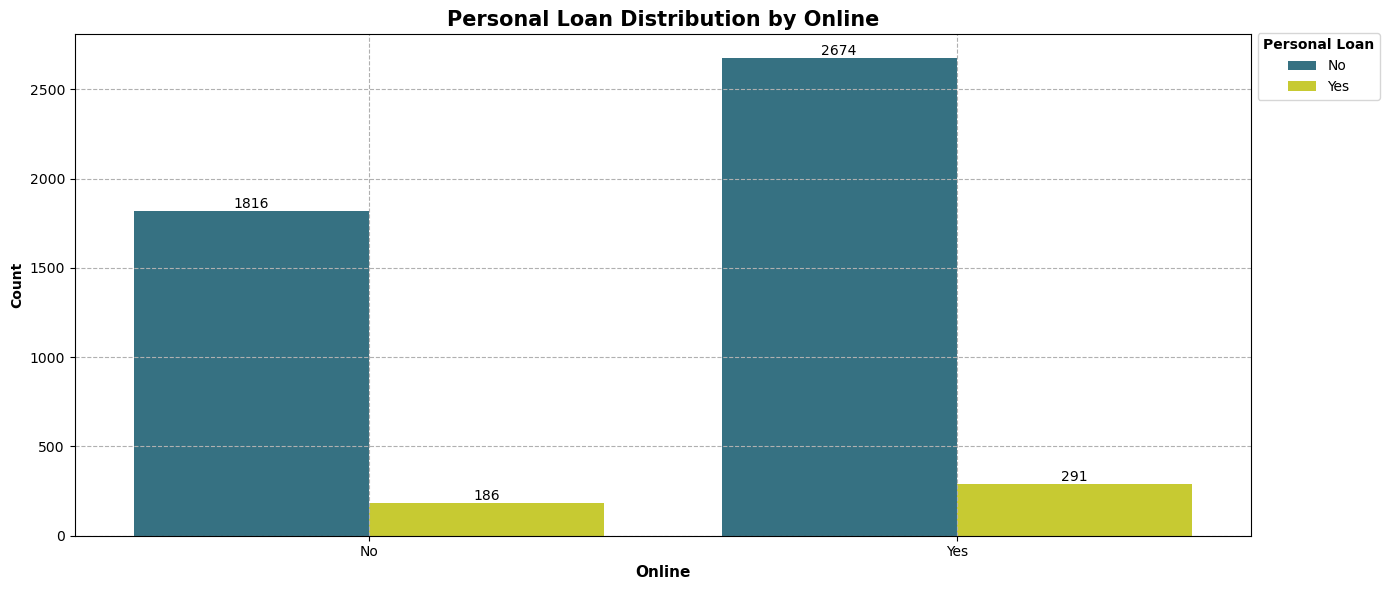

In [14450]:

target_vs_Online = df.groupby(['Personal Loan',
                                  'Online']).size().reset_index(name = 'target_count')
target_vs_Online['target_label'] = target_vs_Online['Personal Loan'].map({
    0:'No', 1:'Yes'})
target_vs_Online['Online_label'] = target_vs_Online['Online'].map({
    0:'No', 1:'Yes'})

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.4, 0.95, target_vs_Online['target_label'].nunique())).tolist()

plt.figure(figsize = (14, 6))
ax = sns.barplot(data = target_vs_Online, x = 'Online_label', y = 'target_count',
                 hue = 'target_label', palette = colors)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Personal Loan Distribution by Online', fontweight = 'bold', fontsize = 15)
plt.xlabel('Online', fontweight = 'bold', fontsize = 11)
plt.ylabel('Count', fontweight = 'bold')
plt.grid(linestyle = '--')
plt.legend(title = 'Personal Loan', loc = 'upper left', bbox_to_anchor = (1, 1.017),
           title_fontproperties = {'weight':'bold'})

plt.tight_layout()
plt.show()

Most individuals have used online services.

The number of people who used online services and took a loan is higher than those who did not use online services.

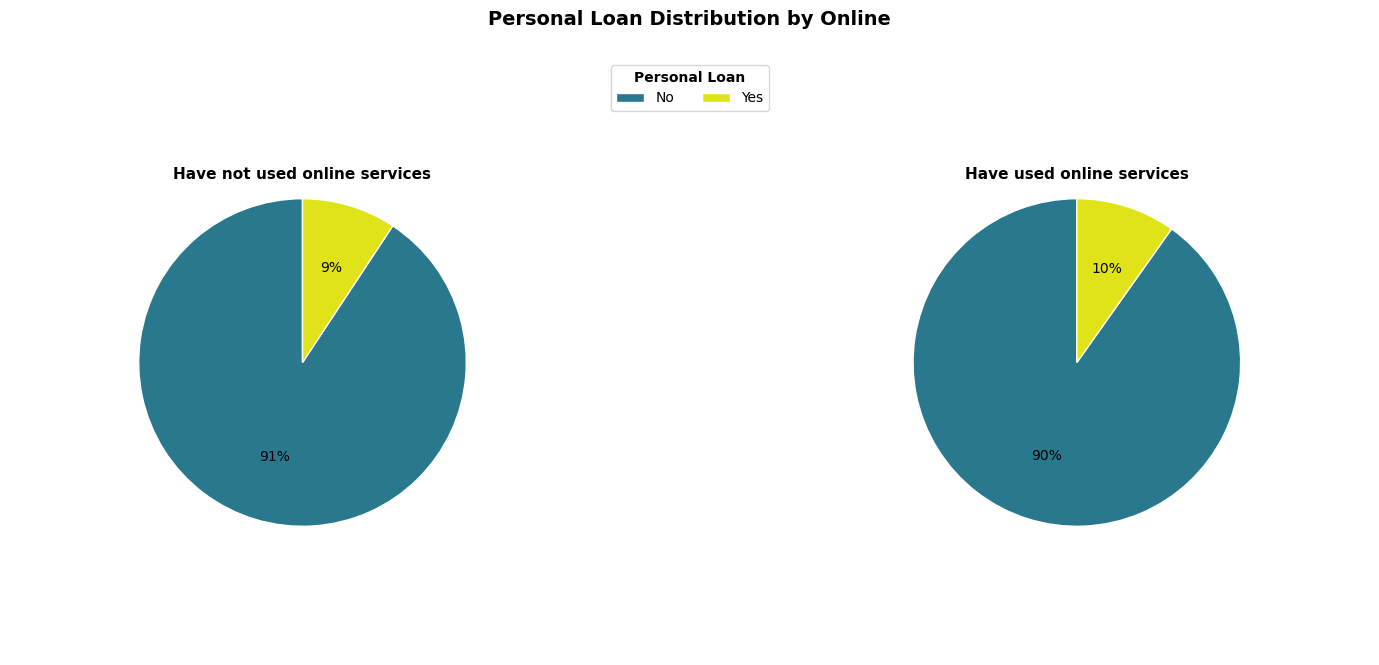

In [14452]:

Online_labels = {
    0: 'Have not used online services',
    1: 'Have used online services'
}
target_labels = {0: 'No', 1: 'Yes'}

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.4, 0.95, len(target_labels)))

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

legend_handles = None

for i, Online_value in enumerate(sorted(df['Online'].unique())):
    ax = axes[i]
    subset = df[df['Online'] == Online_value]
    
    counts = subset['Personal Loan'].value_counts().reindex([0, 1], fill_value = 0)
    
    wedges, _, autotexts = ax.pie(counts, labels = None, autopct = '%1.0f%%', startangle = 90,
                                  colors = colors, wedgeprops = {'edgecolor': 'white'}, radius = 0.7)
    
    ax.set_title(f"{Online_labels[Online_value]}", fontsize = 11, fontweight = 'bold', y = 0.8)
    
    if i == 0:
        legend_handles = wedges

plt.suptitle('Personal Loan Distribution by Online',
             fontsize = 14, fontweight = 'bold', y = 1.10)

fig.legend(legend_handles, ['No', 'Yes'],
           title = 'Personal Loan', loc = 'upper center', bbox_to_anchor = (0.5, 1.02),
           ncol = 2, title_fontproperties = {'weight': 'bold'})

plt.tight_layout()
plt.subplots_adjust(wspace = 0.3, top = 1)
plt.show()

The number of individuals who used online services and took a loan was higher compared to the group who did not use online services and took a loan. However, the above chart shows that approximately the same percentage of each group received a loan, and the difference in counts is likely due to the difference in sample sizes of each group.

It seems that this feature does not have an effect on the likelihood of obtaining a loan.

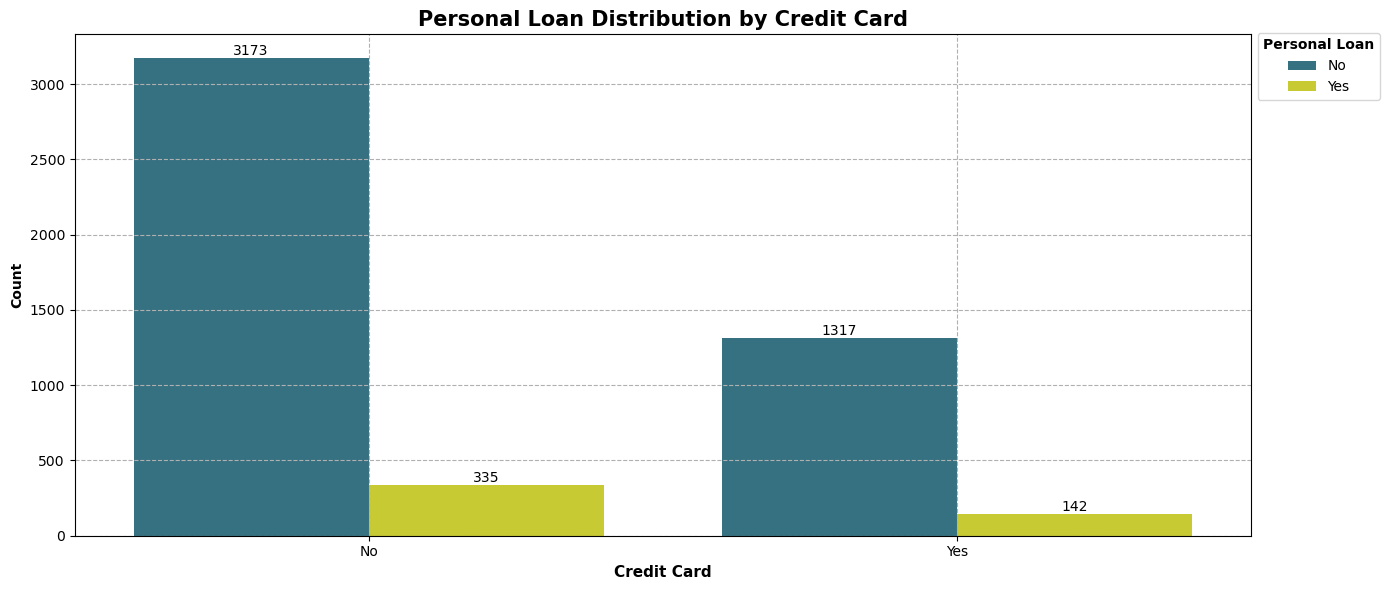

In [14454]:

target_vs_CreditCard = df.groupby(['Personal Loan',
                                  'CreditCard']).size().reset_index(name = 'target_count')
target_vs_CreditCard['target_label'] = target_vs_CreditCard['Personal Loan'].map({
    0:'No', 1:'Yes'})
target_vs_CreditCard['CreditCard_label'] = target_vs_CreditCard['CreditCard'].map({
    0:'No', 1:'Yes'})

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.4, 0.95, target_vs_CreditCard['target_label'].nunique())).tolist()

plt.figure(figsize = (14, 6))
ax = sns.barplot(data = target_vs_CreditCard, x = 'CreditCard_label', y = 'target_count',
                 hue = 'target_label', palette = colors)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Personal Loan Distribution by Credit Card', fontweight = 'bold', fontsize = 15)
plt.xlabel('Credit Card', fontweight = 'bold', fontsize = 11)
plt.ylabel('Count', fontweight = 'bold')
plt.grid(linestyle = '--')
plt.legend(title = 'Personal Loan', loc = 'upper left', bbox_to_anchor = (1, 1.017),
           title_fontproperties = {'weight':'bold'})

plt.tight_layout()
plt.show()

Most individuals have used Credit Card.

The number of people who did not Credit Card and took a loan is higher than those who used Credit Card.

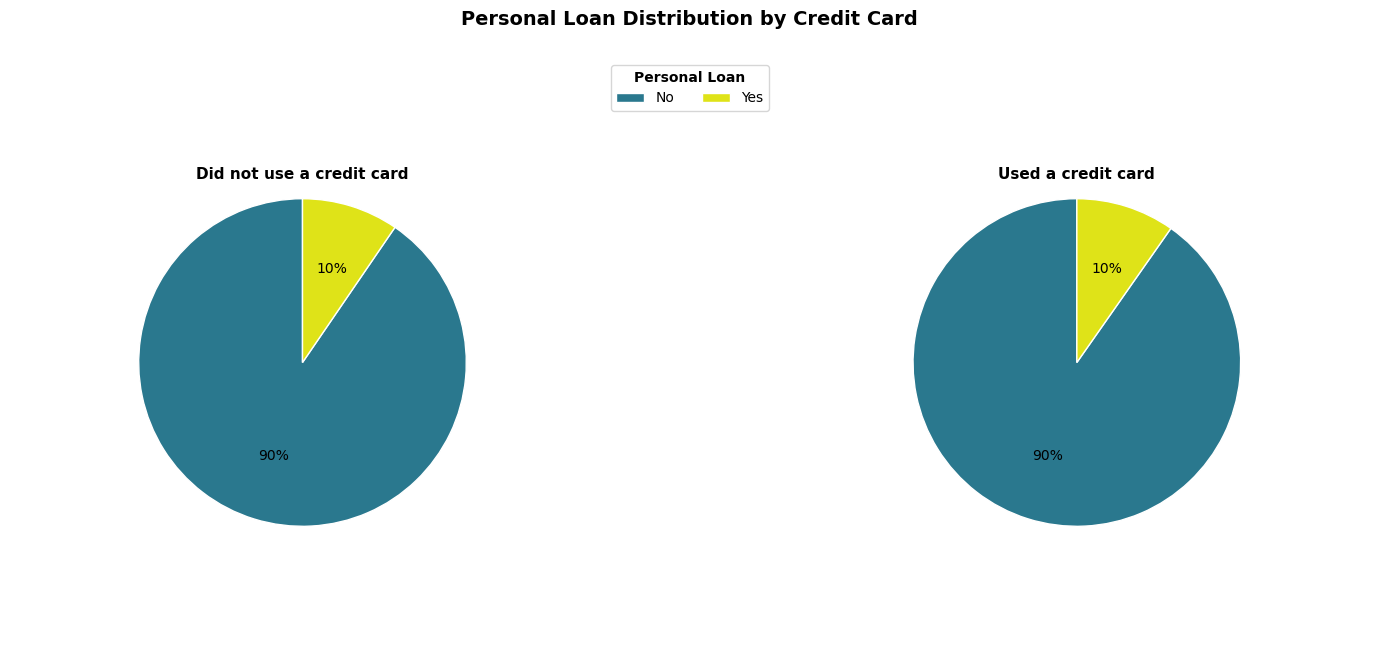

In [14456]:

CreditCard_labels = {
    0: 'Did not use a credit card',
    1: 'Used a credit card'
}
target_labels = {0: 'No', 1: 'Yes'}

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.4, 0.95, len(target_labels)))

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

legend_handles = None

for i, CreditCard_value in enumerate(sorted(df['CreditCard'].unique())):
    ax = axes[i]
    subset = df[df['CreditCard'] == CreditCard_value]
    
    counts = subset['Personal Loan'].value_counts().reindex([0, 1], fill_value = 0)
    
    wedges, _, autotexts = ax.pie(counts, labels = None, autopct = '%1.0f%%', startangle = 90,
                                  colors = colors, wedgeprops = {'edgecolor': 'white'}, radius = 0.7)
    
    ax.set_title(f"{CreditCard_labels[CreditCard_value]}", fontsize = 11,
                 fontweight = 'bold', y = 0.8)
    
    if i == 0:
        legend_handles = wedges

plt.suptitle('Personal Loan Distribution by Credit Card',
             fontsize = 14, fontweight = 'bold', y = 1.10)

fig.legend(legend_handles, ['No', 'Yes'],
           title = 'Personal Loan', loc = 'upper center', bbox_to_anchor = (0.5, 1.02),
           ncol = 2, title_fontproperties = {'weight': 'bold'})

plt.tight_layout()
plt.subplots_adjust(wspace = 0.3, top = 1)
plt.show()

The number of individuals who did not Credit Card and took a loan was higher compared to the group who used Credit Card and took a loan. However, the above chart shows that the same percentage of each group received a loan, and the difference in counts is likely due to the difference in sample sizes of each group.

It seems that this feature does not have an effect on the likelihood of obtaining a loan.

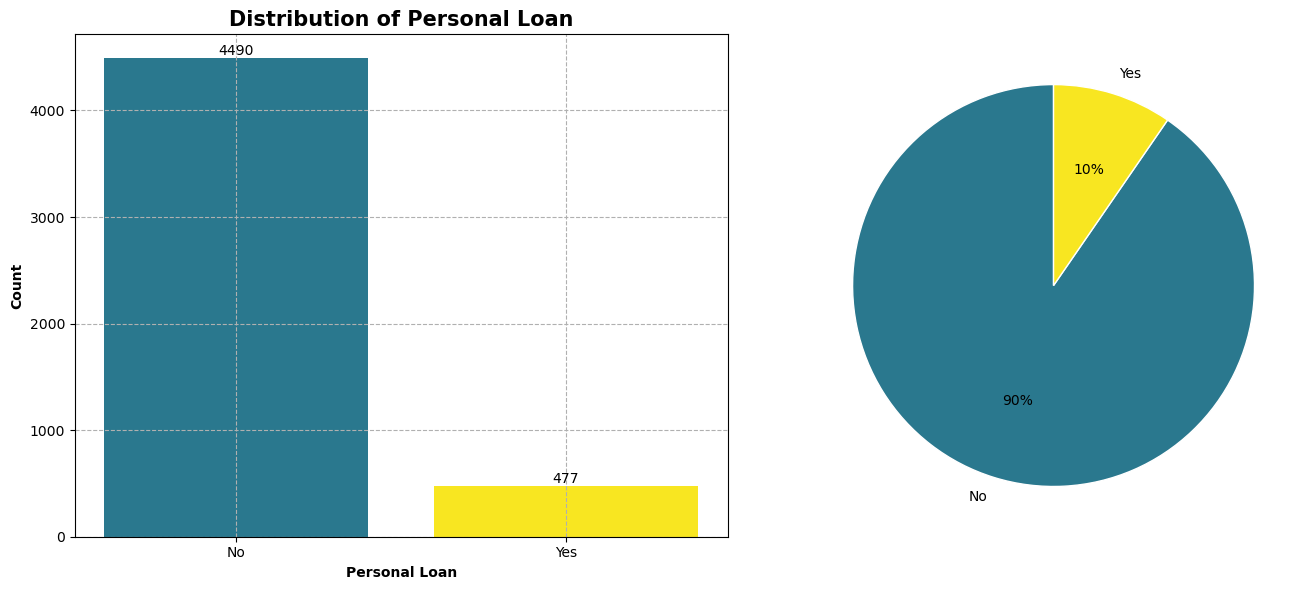

In [14458]:

target_0 = 0
target_1 = 0
for item in df['Personal Loan']:
    if item == 0:
        target_0 += 1
    else:
        target_1 += 1

target = ['No', 'Yes']
values = [target_0, target_1]

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.4, 0.99, len(target)))

fig, ax = plt.subplots(1, 2, figsize = (14, 6))

bar_container = ax[0].bar(target, values, color = colors)
ax[0].bar_label(bar_container)
ax[0].set_title('Distribution of Personal Loan', fontweight = 'bold', fontsize = 15)
ax[0].set_xlabel('Personal Loan', fontweight = 'bold')
ax[0].set_ylabel('Count', fontweight = 'bold')
ax[0].grid(linestyle = '--')

ax[1].pie(values, labels = target , autopct = '%1.0f%%', startangle = 90, colors = colors,
          wedgeprops = {'edgecolor': 'white'})

plt.tight_layout()
plt.show()

Only 10% of the samples in the dataset received a loan, while 90% did not.

In [14460]:
df = df.drop(['latitude', 'longitude', 'primary_city'], axis = 1)
df.corr()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,1.000000,-0.009308,-0.009038,-0.018509,0.014044,-0.018254,-0.026528,0.021401,-0.015133,-0.024485,-0.017003,-0.007664,-0.001297,0.016653
Age,-0.009308,1.000000,0.993973,-0.055443,-0.028458,-0.047203,-0.050590,0.041890,-0.012639,-0.007054,-0.001467,0.007705,0.014096,0.008375
Experience,-0.009038,0.993973,1.000000,-0.046970,-0.028222,-0.052650,-0.048368,0.014298,-0.011051,-0.007581,-0.002117,0.009422,0.014337,0.009793
Income,-0.018509,-0.055443,-0.046970,1.000000,-0.014595,-0.158085,0.645236,-0.186132,0.206968,0.503189,-0.002628,0.170063,0.014238,-0.001289
ZIP Code,0.014044,-0.028458,-0.028222,-0.014595,1.000000,0.011785,-0.002307,-0.018127,0.007466,0.000800,0.005721,0.020224,0.017461,0.007648
Family,-0.018254,-0.047203,-0.052650,-0.158085,0.011785,1.000000,-0.109821,0.065705,-0.021040,0.060989,0.021562,0.013933,0.010959,0.010461
CCAvg,-0.026528,-0.050590,-0.048368,0.645236,-0.002307,-0.109821,1.000000,-0.135240,0.110737,0.366513,0.014146,0.137489,-0.003183,-0.006957
Education,0.021401,0.041890,0.014298,-0.186132,-0.018127,0.065705,-0.135240,1.000000,-0.032961,0.136591,-0.010418,0.014094,-0.014663,-0.010424
Mortgage,-0.015133,-0.012639,-0.011051,0.206968,0.007466,-0.021040,0.110737,-0.032961,1.000000,0.140874,-0.004148,0.089103,-0.003974,-0.008780
Personal Loan,-0.024485,-0.007054,-0.007581,0.503189,0.000800,0.060989,0.366513,0.136591,0.140874,1.000000,0.023161,0.317393,0.008720,0.002830


<span style="font-size:25px; color:orange; font-weight:700;">Logistic Regression</span>

In [14462]:
features = ['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg','Education',
            'Mortgage', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
x = pd.DataFrame(df, columns = features)
y = df['Personal Loan'].values.reshape(-1, 1)

In [14463]:
scaler = preprocessing.StandardScaler()
norm_x = scaler.fit_transform(x)
norm_x_df = pd.DataFrame(norm_x, columns = features)
norm_x_df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
0,-1.735308,-1.776060,-1.677775,-0.539046,-0.961782,1.396458,-0.193124,-1.048125,-0.556293,2.933829,-0.254435,-1.216971,-0.644908
1,-1.734615,-0.030970,-0.100770,-0.864856,-1.440855,0.525075,-0.250474,-1.048125,-0.556293,2.933829,-0.254435,-1.216971,-0.644908
2,-1.733922,-0.554497,-0.451216,-1.364431,0.738502,-1.217690,-0.537224,-1.048125,-0.556293,-0.340852,-0.254435,-1.216971,-0.644908
3,-1.733229,-0.903515,-0.976884,0.568708,0.452376,-1.217690,0.437726,0.142098,-0.556293,-0.340852,-0.254435,-1.216971,-0.644908
4,-1.732536,-0.903515,-1.064496,-0.625929,-0.856838,1.396458,-0.537224,0.142098,-0.556293,-0.340852,-0.254435,-1.216971,1.550608


In [14464]:
x_train, x_test, y_train, y_test = train_test_split(norm_x_df, y.ravel(),
                                                    test_size = 0.2, random_state = 0)
model = LogisticRegression(solver = 'liblinear')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred))
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.9517102615694165
Classification Report: 
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       903
           1       0.79      0.64      0.71        91

    accuracy                           0.95       994
   macro avg       0.88      0.81      0.84       994
weighted avg       0.95      0.95      0.95       994



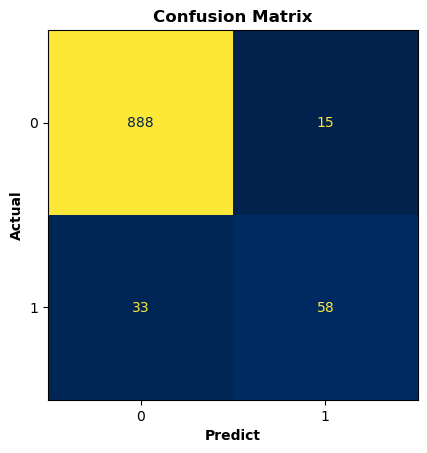

In [14465]:
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap = 'cividis', colorbar = False)
plt.title('Confusion Matrix', fontweight = 'bold')
plt.xlabel('Predict', fontweight = 'bold')
plt.ylabel('Actual', fontweight = 'bold')

plt.show()

In [14466]:
x_train, x_test, y_train, y_test = train_test_split(norm_x_df, y.ravel(),
                                                    test_size = 0.25, random_state = 0)
model = LogisticRegression(solver = 'liblinear')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred))
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.9476650563607085
Classification Report: 
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      1126
           1       0.80      0.59      0.68       116

    accuracy                           0.95      1242
   macro avg       0.88      0.79      0.82      1242
weighted avg       0.94      0.95      0.94      1242



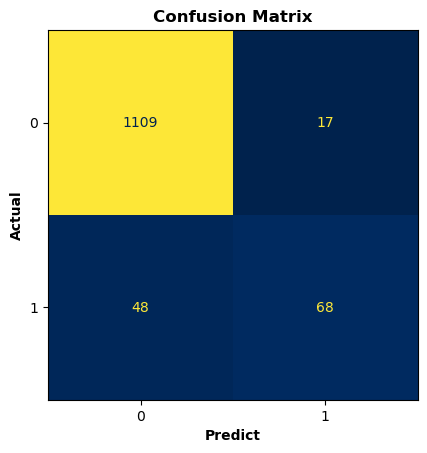

In [14467]:
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap = 'cividis', colorbar = False)
plt.title('Confusion Matrix', fontweight = 'bold')
plt.xlabel('Predict', fontweight = 'bold')
plt.ylabel('Actual', fontweight = 'bold')

plt.show()

In [14468]:
x_train, x_test, y_train, y_test = train_test_split(norm_x_df, y.ravel(),
                                                    test_size = 0.3, random_state = 0)
model = LogisticRegression(solver = 'liblinear')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred))
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.9503688799463448
Classification Report: 
               precision    recall  f1-score   support

           0       0.96      0.99      0.97      1345
           1       0.84      0.61      0.71       146

    accuracy                           0.95      1491
   macro avg       0.90      0.80      0.84      1491
weighted avg       0.95      0.95      0.95      1491



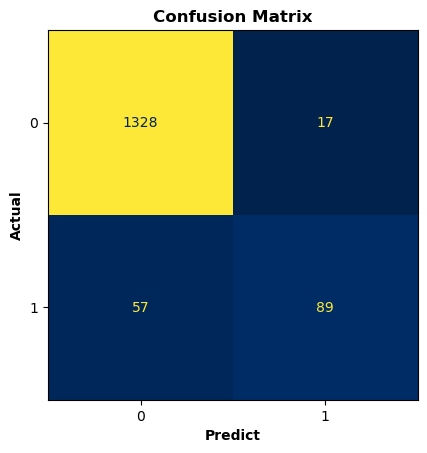

In [14469]:
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap = 'cividis', colorbar = False)
plt.title('Confusion Matrix', fontweight = 'bold')
plt.xlabel('Predict', fontweight = 'bold')
plt.ylabel('Actual', fontweight = 'bold')

plt.show()

In [14470]:
x_train, x_test, y_train, y_test = train_test_split(norm_x_df, y.ravel(),
                                                    test_size = 0.35, random_state = 0)
model = LogisticRegression(solver = 'liblinear')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred))
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.9516963772282921
Classification Report: 
               precision    recall  f1-score   support

           0       0.96      0.99      0.97      1566
           1       0.86      0.62      0.72       173

    accuracy                           0.95      1739
   macro avg       0.91      0.80      0.85      1739
weighted avg       0.95      0.95      0.95      1739



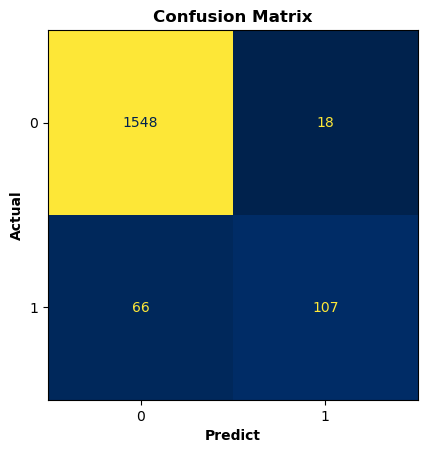

In [14471]:
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap = 'cividis', colorbar = False)
plt.title('Confusion Matrix', fontweight = 'bold')
plt.xlabel('Predict', fontweight = 'bold')
plt.ylabel('Actual', fontweight = 'bold')

plt.show()

In [14472]:
smote = SMOTE(random_state = 0)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)
model = LogisticRegression(solver = 'liblinear') 
model.fit(x_train_resampled, y_train_resampled)
y_pred = model.predict(x_test) 

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred)) 
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.9028177113283496
Classification Report: 
               precision    recall  f1-score   support

           0       0.99      0.90      0.94      1566
           1       0.51      0.90      0.65       173

    accuracy                           0.90      1739
   macro avg       0.75      0.90      0.80      1739
weighted avg       0.94      0.90      0.91      1739



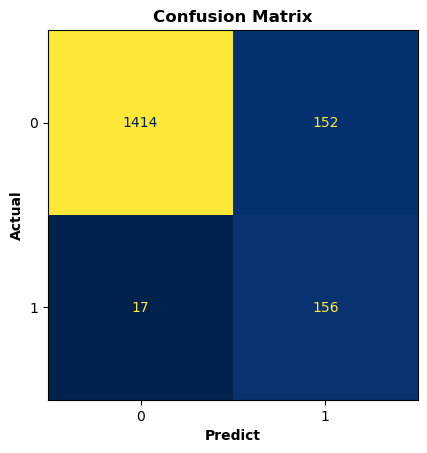

In [14473]:
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap = 'cividis', colorbar = False)
plt.title('Confusion Matrix', fontweight = 'bold')
plt.xlabel('Predict', fontweight = 'bold')
plt.ylabel('Actual', fontweight = 'bold')

plt.show()

In [14474]:
x_train, x_test, y_train, y_test = train_test_split(norm_x_df, y.ravel(),
                                                    test_size = 0.35, random_state = 0)
model = LogisticRegression(solver = 'liblinear', class_weight = {0: 2, 1: 5})
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred))
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.9430707303047728
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.96      0.97      1566
           1       0.70      0.76      0.73       173

    accuracy                           0.94      1739
   macro avg       0.83      0.86      0.85      1739
weighted avg       0.95      0.94      0.94      1739



<span style="font-size:25px; color:green; font-weight:700;">Finall Model for Logistic Regression</span>

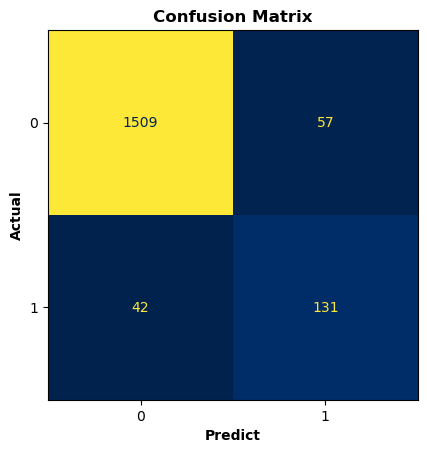

In [14476]:
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap = 'cividis', colorbar = False)
plt.title('Confusion Matrix', fontweight = 'bold')
plt.xlabel('Predict', fontweight = 'bold')
plt.ylabel('Actual', fontweight = 'bold')

plt.show()

In [14477]:
data_input =[[5071,    # ID
              42,      # Age
              16,      # Experience
              30,      # Income
              92037,   # ZIP Code
              3,       # Family
              1.2,     # CCAvg
              3,       # Education = {3: Advanced/Professional}
              0,       # Mortgage
              1,       # Securities Account
              0,       # CD Account
              1,       # Online
              1]]      # Credit Card

data_input_scaled = scaler.transform(data_input)
LogisticRegression_result = model.predict(data_input_scaled)

print('Personal Loan: ', LogisticRegression_result)

Personal Loan:  [0]


In [14478]:
y_prob = model.predict_proba(x_test)[:,1]
cost = log_loss(y_test, y_prob)
print("Cost Function for Logistic Regression Model:", cost)

Cost Function for Logistic Regression Model: 0.13963358532764295


<span style="font-size:25px; color:orange; font-weight:700;">Naive Bayes</span>

In [14480]:
scaler = preprocessing.MinMaxScaler(feature_range = (0, 1))
norm_x = scaler.fit_transform(x)
norm_x_df = pd.DataFrame(norm_x, columns = features)

x_train, x_test, y_train, y_test = train_test_split(norm_x_df, y.ravel(),
                                                    test_size = 0.2, random_state = 0)

model = MultinomialNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred))
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.9104627766599598
Classification Report: 
               precision    recall  f1-score   support

           0       0.91      1.00      0.95       903
           1       1.00      0.02      0.04        91

    accuracy                           0.91       994
   macro avg       0.96      0.51      0.50       994
weighted avg       0.92      0.91      0.87       994



In [14481]:
smote = SMOTE(random_state = 0)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)
model = MultinomialNB()
model.fit(x_train_resampled, y_train_resampled)
y_pred = model.predict(x_test) 

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred)) 
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.8611670020120724
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.88      0.92       903
           1       0.36      0.69      0.48        91

    accuracy                           0.86       994
   macro avg       0.67      0.79      0.70       994
weighted avg       0.91      0.86      0.88       994



In [14482]:
rus = RandomUnderSampler(random_state = 0)
x_train_resampled, y_train_resampled = rus.fit_resample(x_train, y_train)
model = MultinomialNB()
model.fit(x_train_resampled, y_train_resampled)
y_pred = model.predict(x_test) 

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred)) 
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.8561368209255533
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.87      0.92       903
           1       0.35      0.69      0.47        91

    accuracy                           0.86       994
   macro avg       0.66      0.78      0.69       994
weighted avg       0.91      0.86      0.88       994



In [14483]:
x_train, x_test, y_train, y_test = train_test_split(norm_x_df, y.ravel(),
                                                    test_size = 0.3, random_state = 0)

model = GaussianNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred))
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.8853118712273642
Classification Report: 
               precision    recall  f1-score   support

           0       0.95      0.92      0.94      1345
           1       0.44      0.59      0.50       146

    accuracy                           0.89      1491
   macro avg       0.70      0.75      0.72      1491
weighted avg       0.90      0.89      0.89      1491



In [14484]:

scaler = preprocessing.MinMaxScaler(feature_range = (0, 1))
norm_x = scaler.fit_transform(x)
norm_x_df = pd.DataFrame(norm_x, columns = x.columns)

x_train, x_test, y_train, y_test = train_test_split(norm_x_df, y.ravel(),
                                                    test_size = 0.3, random_state = 0)
smote = SMOTE(random_state = 0)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)
model = ComplementNB()
model.fit(x_train_resampled, y_train_resampled)
y_proba = model.predict_proba(x_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred)) 
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.8698859825620389
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.88      0.92      1345
           1       0.41      0.73      0.52       146

    accuracy                           0.87      1491
   macro avg       0.69      0.81      0.72      1491
weighted avg       0.91      0.87      0.89      1491



In [14485]:
x_train, x_test, y_train, y_test = train_test_split(norm_x_df, y.ravel(),
                                                    test_size = 0.3, random_state = 0)
smote = SMOTE(random_state = 0)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)
model = GaussianNB()
model.fit(x_train_resampled, y_train_resampled)
y_pred = model.predict(x_test) 

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred)) 
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.8900067069081153
Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.89      0.94      1345
           1       0.47      0.85      0.60       146

    accuracy                           0.89      1491
   macro avg       0.72      0.87      0.77      1491
weighted avg       0.93      0.89      0.90      1491



<span style="font-size:25px; color:green; font-weight:700;">Finall Model for Naive Bayes</span>

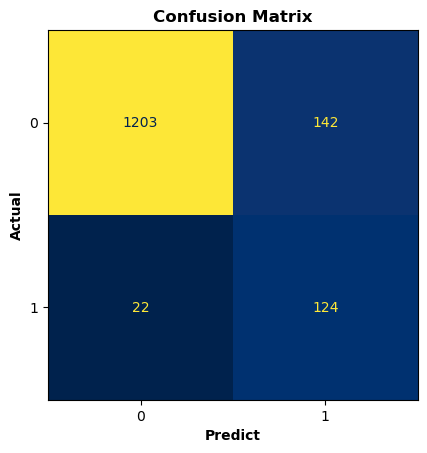

In [14487]:
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap = 'cividis', colorbar = False)
plt.title('Confusion Matrix', fontweight = 'bold')
plt.xlabel('Predict', fontweight = 'bold')
plt.ylabel('Actual', fontweight = 'bold')

plt.show()

In [14488]:
data_input =[[5071,    # ID
              42,      # Age
              16,      # Experience
              30,      # Income
              92037,   # ZIP Code
              3,       # Family
              1.2,     # CCAvg
              3,       # Education = {3: Advanced/Professional}
              0,       # Mortgage
              1,       # Securities Account
              0,       # CD Account
              1,       # Online
              1]]      # Credit Card

data_input_scaled = scaler.transform(data_input)
NaiveBayes_result = model.predict(data_input_scaled)

print('Personal Loan: ', NaiveBayes_result)

Personal Loan:  [0]


In [14489]:
y_prob = model.predict_proba(x_test)[:,1]
cost = log_loss(y_test, y_prob)
print("Cost Function for Naive Bayes Model:", cost)

Cost Function for Naive Bayes Model: 0.47960291397518506


<span style="font-size:25px; color:orange; font-weight:700;">KNN</span>

In [14491]:
features = ['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg','Education',
            'Mortgage', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
x = pd.DataFrame(df, columns = features).values
y = df['Personal Loan'].values.reshape(-1, 1)

In [14492]:
scaler = preprocessing.MinMaxScaler(feature_range = (0, 1))
norm_x = scaler.fit_transform(x)
norm_x_df = pd.DataFrame(norm_x, columns = features)
norm_x_df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
0,0.0000,0.045455,0.023256,0.189815,0.941930,1.000000,0.16,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0002,0.500000,0.441860,0.120370,0.930207,0.666667,0.15,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0004,0.363636,0.348837,0.013889,0.983534,0.000000,0.10,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0006,0.272727,0.209302,0.425926,0.976532,0.000000,0.27,0.5,0.0,0.0,0.0,0.0,0.0
4,0.0008,0.272727,0.186047,0.171296,0.944498,1.000000,0.10,0.5,0.0,0.0,0.0,0.0,1.0


In [14493]:
x_train, x_test, y_train, y_test = train_test_split(norm_x_df, y.ravel(),
                                                    test_size = 0.3, random_state = 0)

model = KNeighborsClassifier(1)
model.fit(x_train, y_train)
y_pred = model.predict(x_test) 

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred)) 
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.9590878604963112
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1345
           1       0.88      0.67      0.76       146

    accuracy                           0.96      1491
   macro avg       0.92      0.83      0.87      1491
weighted avg       0.96      0.96      0.96      1491



In [14494]:
x_train, x_test, y_train, y_test = train_test_split(norm_x_df, y.ravel(),
                                                    test_size = 0.2, random_state = 0)
smote = SMOTE(random_state = 0)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)
model = KNeighborsClassifier(1)
model.fit(x_train, y_train)
y_pred = model.predict(x_test) 

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred)) 
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.9607645875251509
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       903
           1       0.85      0.69      0.76        91

    accuracy                           0.96       994
   macro avg       0.91      0.84      0.87       994
weighted avg       0.96      0.96      0.96       994



In [14495]:
k = 20
Acc = np.zeros((k)) 

for i in range(1, k + 1):
    model = KNeighborsClassifier(n_neighbors = i)
    model.fit(x_train, y_train.ravel())
    y_pred = model.predict(x_test)
    Acc[i - 1] = metrics.accuracy_score(y_test, y_pred)  
    
Acc

array([0.96076459, 0.95070423, 0.95774648, 0.94466801, 0.95070423,
       0.94064386, 0.94366197, 0.93863179, 0.94064386, 0.93863179,
       0.94064386, 0.93460765, 0.93561368, 0.93360161, 0.93561368,
       0.93360161, 0.93360161, 0.93259557, 0.93360161, 0.93259557])

In [14496]:
print(np.max(Acc))
print(np.min(Acc))

0.9607645875251509
0.9325955734406438


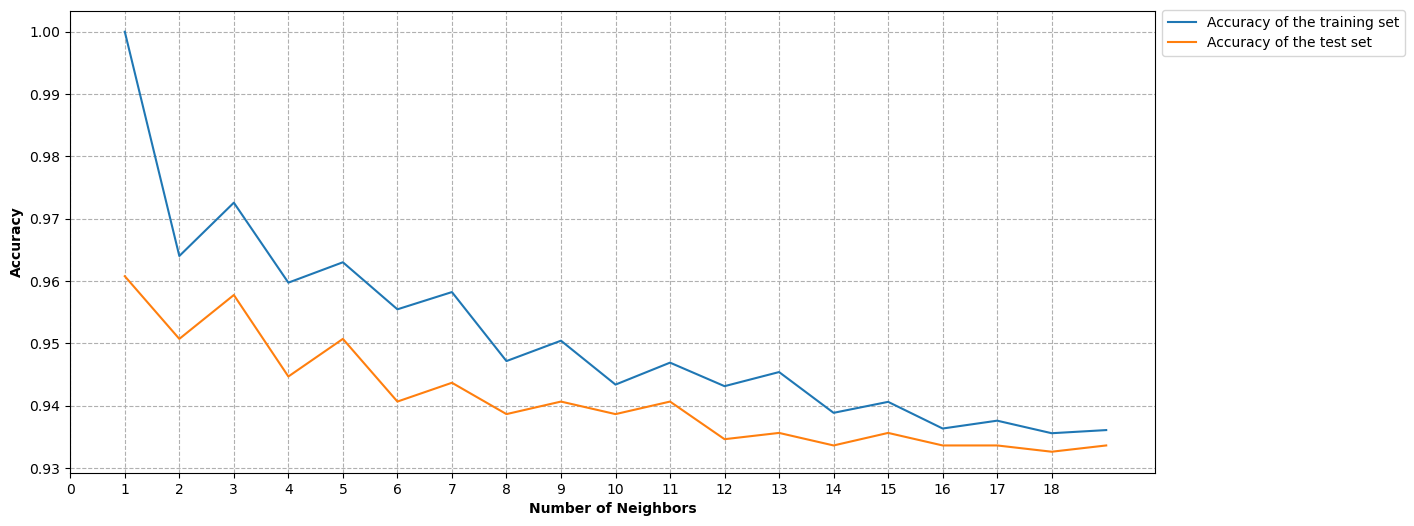

In [14497]:
training_acc = []
test_acc = []

neighbors_setting = range(1, 20)

for n_neighbors in neighbors_setting:
    knn = KNeighborsClassifier(n_neighbors)
    knn.fit(x_train, y_train.ravel())
    training_acc.append(knn.score(x_train, y_train))
    test_acc.append(knn.score(x_test, y_test))
    
plt.figure(figsize = (14, 6))    
plt.plot(neighbors_setting, training_acc, label = "Accuracy of the training set")
plt.plot(neighbors_setting, test_acc, label = "Accuracy of the test set")
plt.xlabel("Number of Neighbors", fontweight = 'bold')
plt.xticks(range(0, 19, 1))
plt.ylabel("Accuracy", fontweight = 'bold')
plt.grid(linestyle = '--')
plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1.017),
          title_fontproperties = {'weight':'bold'})
plt.show()

In [14498]:
parameters = {"n_neighbors": range(1, 50)}
grid_kn = GridSearchCV(
    estimator = knn, 
    param_grid = parameters, 
    scoring = "accuracy",
    cv = 5, 
    verbose = 1,
    n_jobs = -1, 
)
grid_kn.fit(x_train, y_train.ravel())

Fitting 5 folds for each of 49 candidates, totalling 245 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=19), n_jobs=-1,
             param_grid={'n_neighbors': range(1, 50)}, scoring='accuracy',
             verbose=1)

In [14499]:
grid_kn.best_params_

{'n_neighbors': 3}

In [14500]:
x_train, x_test, y_train, y_test = train_test_split(norm_x_df, y.ravel(),
                                                    test_size = 0.2, random_state = 0)
smote = SMOTE(random_state = 0)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)
model = KNeighborsClassifier(1)
model.fit(x_train, y_train)
y_pred = model.predict(x_test) 

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred)) 
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.9607645875251509
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       903
           1       0.85      0.69      0.76        91

    accuracy                           0.96       994
   macro avg       0.91      0.84      0.87       994
weighted avg       0.96      0.96      0.96       994



In [14501]:
y_prob = model.predict_proba(x_test)[:,1]
cost = log_loss(y_test, y_prob)
print("Cost Function for Naive Bayes Model:", cost)

Cost Function for Naive Bayes Model: 1.4141876078225042


In [14502]:
x_train, x_test, y_train, y_test = train_test_split(norm_x_df, y.ravel(),
                                                    test_size = 0.2, random_state = 0)
smote = SMOTE(random_state = 0)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)
model = KNeighborsClassifier(3)
model.fit(x_train, y_train)
y_pred = model.predict(x_test) 

print('Accuracy: ', metrics.accuracy_score(y_test, y_pred)) 
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.9577464788732394
Classification Report: 
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.98      0.55      0.70        91

    accuracy                           0.96       994
   macro avg       0.97      0.77      0.84       994
weighted avg       0.96      0.96      0.95       994



In [14503]:
y_prob = model.predict_proba(x_test)[:,1]
cost = log_loss(y_test, y_prob)
print("Cost Function for Naive Bayes Model:", cost)

Cost Function for Naive Bayes Model: 0.5941555211631838


<span style="font-size:25px; color:green; font-weight:700;">Finall Model for KNN</span>

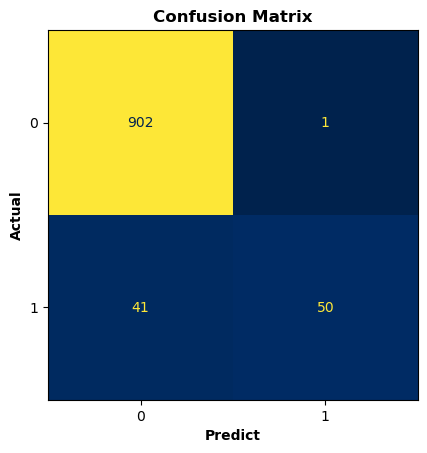

In [14505]:
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap = 'cividis', colorbar = False)
plt.title('Confusion Matrix', fontweight = 'bold')
plt.xlabel('Predict', fontweight = 'bold')
plt.ylabel('Actual', fontweight = 'bold')

plt.show()

In [14506]:
data_input =[[5071,    # ID
              42,      # Age
              16,      # Experience
              30,      # Income
              92037,   # ZIP Code
              3,       # Family
              1.2,     # CCAvg
              3,       # Education = {3: Advanced/Professional}
              0,       # Mortgage
              1,       # Securities Account
              0,       # CD Account
              1,       # Online
              1]]      # Credit Card

data_input_scaled = scaler.transform(data_input)
KNN_result = model.predict(data_input_scaled)

print('Personal Loan: ', KNN_result)

Personal Loan:  [0]


The comparison of cost function values for different algorithms is as follows:

Logistic Regression < Naive Bayes < KNN